## 1. Apply different noise types (Gaussian, Salt & Pepper) to an image and use the following filters to remove noise:
i)	Mean Filter

ii)	Gaussian Filter

Compare the effectiveness of each method. Which filter works best for which type of noise?

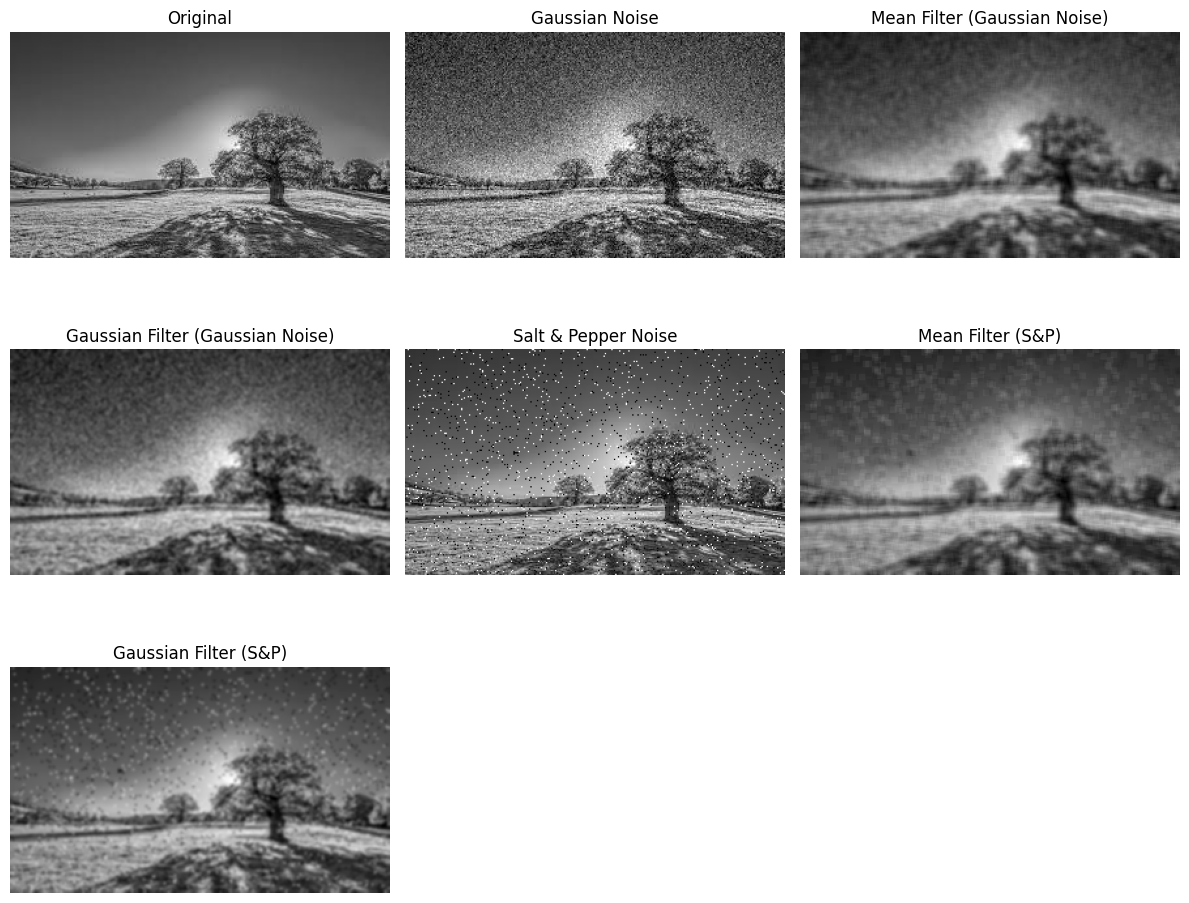

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --------------------------
# Load Image
# --------------------------
img = cv2.imread('image.jpg', 0)

# --------------------------
# Add Gaussian Noise
# --------------------------
mean = 0
sigma = 25
gaussian_noise = np.random.normal(mean, sigma, img.shape)
gaussian_img = img + gaussian_noise
gaussian_img = np.clip(gaussian_img, 0, 255).astype(np.uint8)

# --------------------------
# Add Salt & Pepper Noise
# --------------------------
sp_img = img.copy()
prob = 0.02

salt = np.random.rand(*img.shape) < prob
sp_img[salt] = 255

pepper = np.random.rand(*img.shape) < prob
sp_img[pepper] = 0

# --------------------------
# Mean Filter
# --------------------------
mean_gaussian = cv2.blur(gaussian_img, (5,5))
mean_sp = cv2.blur(sp_img, (5,5))

# --------------------------
# Gaussian Filter
# --------------------------
gauss_gaussian = cv2.GaussianBlur(gaussian_img, (5,5), 0)
gauss_sp = cv2.GaussianBlur(sp_img, (5,5), 0)

# --------------------------
# Plot Results
# --------------------------
titles = [
    "Original",
    "Gaussian Noise",
    "Mean Filter (Gaussian Noise)",
    "Gaussian Filter (Gaussian Noise)",
    "Salt & Pepper Noise",
    "Mean Filter (S&P)",
    "Gaussian Filter (S&P)"
]

images = [
    img,
    gaussian_img,
    mean_gaussian,
    gauss_gaussian,
    sp_img,
    mean_sp,
    gauss_sp
]

plt.figure(figsize=(12,10))

for i in range(len(images)):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

## 2. Perform histogram equalization on a low-contrast image.
i)	Compare the histogram before and after equalization.

ii)	How does histogram equalization affect image brightness and contrast?

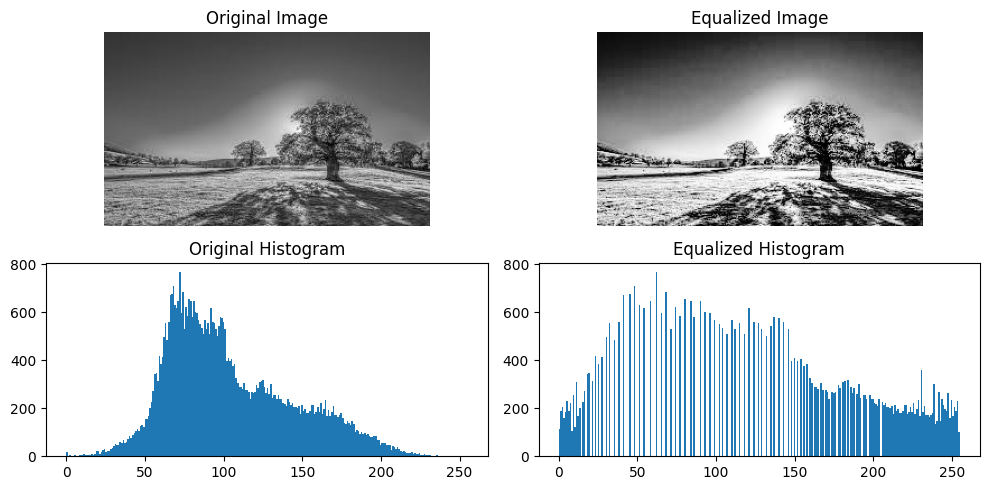

In [1]:
import cv2
import matplotlib.pyplot as plt

# --------------------------
# Load Low Contrast Image
# --------------------------
img = cv2.imread('image.jpg', 0)

# --------------------------
# Histogram Equalization
# --------------------------
equalized = cv2.equalizeHist(img)
# --------------------------
# Plot Images
# --------------------------
plt.figure(figsize=(10,5))

plt.subplot(2,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(equalized, cmap='gray')
plt.title("Equalized Image")
plt.axis('off')

# --------------------------
# Histograms
# --------------------------
plt.subplot(2,2,3)
plt.hist(img.ravel(), bins=256)
plt.title("Original Histogram")

plt.subplot(2,2,4)
plt.hist(equalized.ravel(), bins=256)
plt.title("Equalized Histogram")

plt.tight_layout()
plt.show()

#### (i) Histogram Comparison (Before vs After Equalization)
##### Before Equalization:

The histogram is narrow and concentrated

Pixel intensities are limited to a small range

The image appears dull and low contrast

##### After Equalization:

The histogram is spread across the full intensity range (0–255)

Pixel distribution becomes more uniform

The image appears clearer with improved contrast

#### (ii) Effect on Brightness and Contrast
##### Contrast:
Histogram equalization significantly increases contrast.

It enhances the difference between dark and bright regions.

As a result, image details become more visible
##### Brightness:
The overall brightness may change slightly.

The image may appear brighter or more balanced.

This happens because pixel intensities are redistributed.

## 3. Segment an object from an image using different thresholding techniques:
i)	Global Thresholding (Otsu’s method)

ii)	Adaptive Thresholding

iii)	Compare results and discuss when adaptive thresholding is preferable over global thresholding.

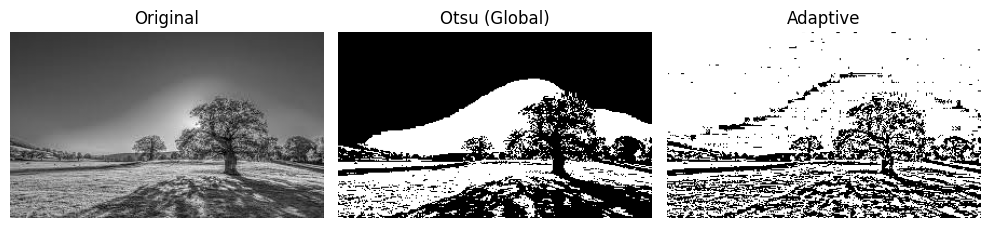

In [1]:
import cv2
import matplotlib.pyplot as plt

# --------------------------
# Load Image
# --------------------------
img = cv2.imread('image.jpg',0)

# --------------------------
# (i) Otsu Thresholding
# --------------------------
_, otsu = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# --------------------------
# (ii) Adaptive Thresholding
# --------------------------
adaptive = cv2.adaptiveThreshold(
    img, 255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY,
    11, 2
)

# --------------------------
# Plot
# --------------------------
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(otsu, cmap='gray')
plt.title("Otsu (Global)")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(adaptive, cmap='gray')
plt.title("Adaptive")
plt.axis('off')

plt.tight_layout()
plt.show()

#### (i) Global Thresholding (Otsu)
Uses one global threshold.

Best for uniform lighting.

Fast and simple.

#### (ii) Adaptive Thresholding
Uses different thresholds for different regions.

Works well in uneven lighting.

#### (iii) Comparison
Otsu fails in shadows or varying light.

Adaptive works better in complex lighting

## 4. Load a grayscale image and apply the following edge detection techniques: 
i)	Sobel Operator

ii)	Prewitt Operator

iii)	Canny Edge Detector

Compare the results by analyzing the sharpness and completeness of detected edges. 

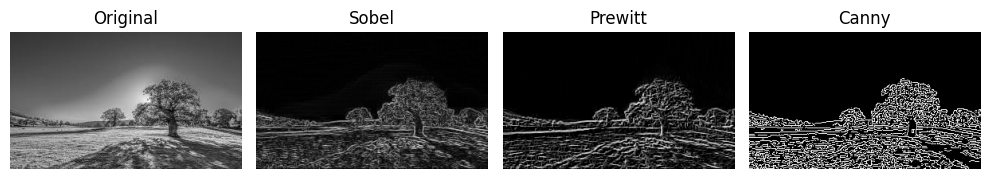

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --------------------------
# Load Image
# --------------------------
img = cv2.imread('image.jpg', 0)

# --------------------------
# (i) Sobel Operator
# --------------------------
sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
sobel = cv2.magnitude(sobelx, sobely)
# --------------------------
# (ii) Prewitt Operator
# --------------------------
kernelx = np.array([[1,0,-1],[1,0,-1],[1,0,-1]])
kernely = np.array([[1,1,1],[0,0,0],[-1,-1,-1]])

prewittx = cv2.filter2D(img, -1, kernelx)
prewitty = cv2.filter2D(img, -1, kernely)
prewitt = cv2.magnitude(prewittx.astype(float), prewitty.astype(float))

# --------------------------
# (iii) Canny Edge Detector
# --------------------------
canny = cv2.Canny(img, 100, 200)

# --------------------------
# Plot
# --------------------------
plt.figure(figsize=(10,4))

plt.subplot(1,4,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(sobel, cmap='gray')
plt.title("Sobel")
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(prewitt, cmap='gray')
plt.title("Prewitt")
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(canny, cmap='gray')
plt.title("Canny")
plt.axis('off')

plt.tight_layout()
plt.show()

#### (i) Sobel Operator
Detects edges using gradient (horizontal + vertical)

Produces smooth edges

Slightly sensitive to noise

#### (ii) Prewitt Operator
Similar to Sobel but simpler kernel

Less accurate than Sobel

Edges are less sharp
#### (iii) Canny Edge Detector
Multi-step method (noise reduction + gradient + thresholding)

Produces very sharp and thin edges

Most accurate among the three

### Comparison (Sharpness & Completeness)
Method	  Sharpness	            Edge Completeness	  Noise Sensitivity

Sobel	  Medium	            Good	              Medium

Prewitt	  Low	                Moderate	          High

Canny	  High (very sharp)	    Very complete	      Low

## 5.Write a MATLAB/Python program to Character Segment of an image.

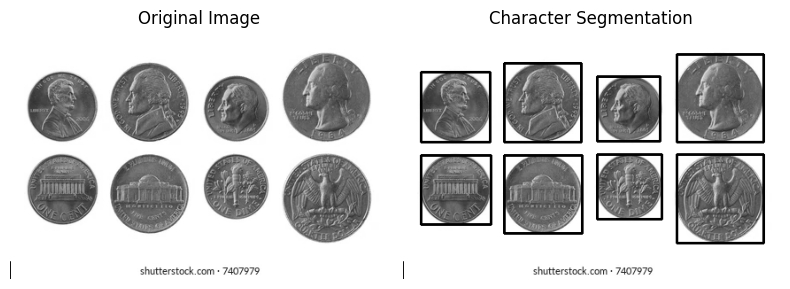

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --------------------------
# Load Image
# --------------------------
img = cv2.imread('image3.webp', 0)

# --------------------------
# Threshold (Binary Image)
# --------------------------
_, thresh = cv2.threshold(img, 150, 255, cv2.THRESH_BINARY_INV)

# --------------------------
# Find Contours (Characters)
# --------------------------
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Sort contours from left to right
contours = sorted(contours, key=lambda c: cv2.boundingRect(c)[0])

# --------------------------
# Draw Bounding Boxes
# --------------------------
output = img.copy()

for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    
    # Filter small noise
    if w > 10 and h > 15:
        cv2.rectangle(output, (x,y), (x+w, y+h), (0,255,0), 2)

# --------------------------
# Show Result
# --------------------------
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Character Segmentation")
plt.axis('off')

plt.tight_layout()
plt.show()

## 6.Write a MATLAB/Python program to read ‘rice.tif’ image, count number of 

Correct Rice Count: 51


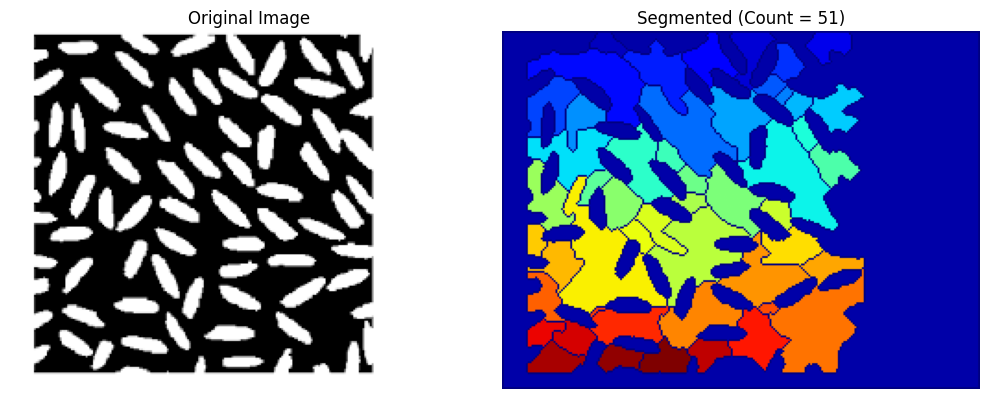

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --------------------------
# Read Image
# --------------------------
img = cv2.imread('image_4.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# --------------------------
# Threshold
# --------------------------
_, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Invert (rice = white)
thresh = cv2.bitwise_not(thresh)

# --------------------------
# Noise Removal
# --------------------------
kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

# --------------------------
# Distance Transform
# --------------------------
dist = cv2.distanceTransform(opening, cv2.DIST_L2, 5)

_, sure_fg = cv2.threshold(dist, 0.4*dist.max(), 255, 0)
sure_fg = np.uint8(sure_fg)

# Background
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# Unknown region
unknown = cv2.subtract(sure_bg, sure_fg)

# --------------------------
# Marker Labelling
# --------------------------
_, markers = cv2.connectedComponents(sure_fg)

markers = markers + 1
markers[unknown == 255] = 0

# --------------------------
# Watershed
# --------------------------
markers = cv2.watershed(img, markers)

# Count objects
count = len(np.unique(markers)) - 2

print("Correct Rice Count:", count)

# --------------------------
# Show Output
# --------------------------
plt.figure(figsize=(10,4))

# Original Image
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis('off')

# Segmented Result
plt.subplot(1,2,2)
plt.imshow(markers, cmap='jet')
plt.title(f"Segmented (Count = {count})")
plt.axis('off')

plt.tight_layout()
plt.show()

## 7.Write a MATLAB/Python program to read an image and perform convolution with 3X3 mask.

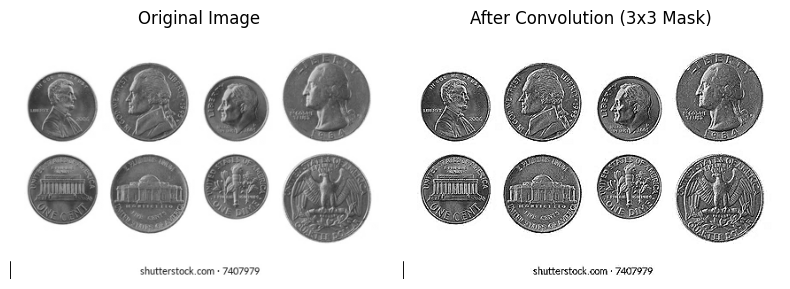

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --------------------------
# Read Image
# --------------------------
img = cv2.imread('image3.webp', 0)

# --------------------------
# Define 3x3 Mask (Example: Sharpening)
# --------------------------
kernel = np.array([[0, -1, 0],
                   [-1, 5, -1],
                   [0, -1, 0]])

# --------------------------
# Convolution
# --------------------------
output = cv2.filter2D(img, -1, kernel)

# --------------------------
# Show Result
# --------------------------
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(output, cmap='gray')
plt.title("After Convolution (3x3 Mask)")
plt.axis('off')

plt.tight_layout()
plt.show()

## 8.Develop a MATLAB/Python program that performs a two-scale image decomposition using the wavelet transform, and generate plots to visualize the results.

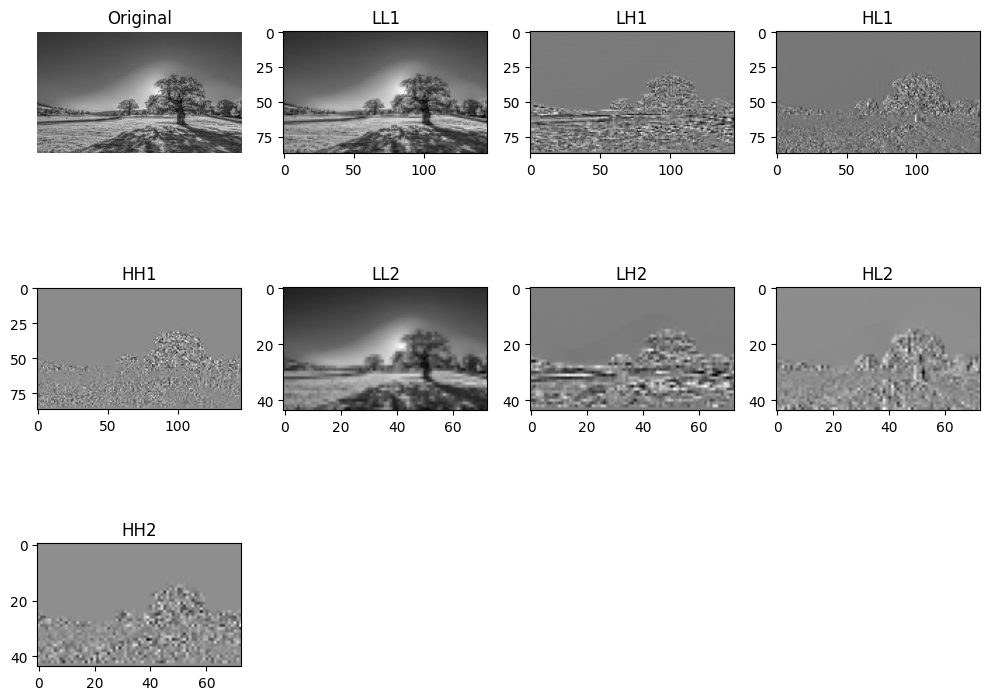

In [19]:
import cv2
import pywt
import matplotlib.pyplot as plt

# --------------------------
# Read Image
# --------------------------
img = cv2.imread('image.jpg', 0)

# --------------------------
# 1st Level Decomposition
# --------------------------
coeffs1 = pywt.dwt2(img, 'haar')
LL1, (LH1, HL1, HH1) = coeffs1

# --------------------------
# 2nd Level Decomposition (on LL1)
# --------------------------
coeffs2 = pywt.dwt2(LL1, 'haar')
LL2, (LH2, HL2, HH2) = coeffs2

# --------------------------
# Plot Results
# --------------------------
plt.figure(figsize=(10,8))

# Original
plt.subplot(3,4,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

# Level 1
plt.subplot(3,4,2)
plt.imshow(LL1, cmap='gray')
plt.title("LL1")

plt.subplot(3,4,3)
plt.imshow(LH1, cmap='gray')
plt.title("LH1")

plt.subplot(3,4,4)
plt.imshow(HL1, cmap='gray')
plt.title("HL1")

plt.subplot(3,4,5)
plt.imshow(HH1, cmap='gray')
plt.title("HH1")

# Level 2
plt.subplot(3,4,6)
plt.imshow(LL2, cmap='gray')
plt.title("LL2")

plt.subplot(3,4,7)
plt.imshow(LH2, cmap='gray')
plt.title("LH2")

plt.subplot(3,4,8)
plt.imshow(HL2, cmap='gray')
plt.title("HL2")

plt.subplot(3,4,9)
plt.imshow(HH2, cmap='gray')
plt.title("HH2")

plt.tight_layout()
plt.show()

In [16]:
!pip install PyWavelets